*IMPORT LIBRARIES*

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

*Import dataset*

In [3]:
df = pd.read_csv(r"Sales_Performance.csv")

*Modify column names for ease of access*

In [4]:
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.rename(columns={'total_sales': 'revenue'}, inplace=True)

*create columns for dates*

In [5]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['quarter'] = df['order_date'].dt.quarter
df['month_name'] = df['order_date'].dt.month_name()

*Total Revenue*

In [6]:
Total_Revenue = df['revenue'].sum()

print(f'Total Revenue: {Total_Revenue:,.2f}')

Total Revenue: 392,334.83


*Revenue, sales and profits by regions*

In [7]:
rev_table = df.groupby(['region']).agg(
    Revenue=('revenue', 'sum'),
    Sales=('units_sold', 'sum'),
    Profit=('profit', 'sum')
).reset_index()

rev_table = rev_table.sort_values(by='Revenue', ascending=False)

rev_table

,region,Revenue,Sales,Profit
0,East,104754.1345,440,24204.0145
3,West,102258.2880,453,23006.2180
2,South,101928.9770,442,23353.0070
1,North,83393.4310,405,15928.8510


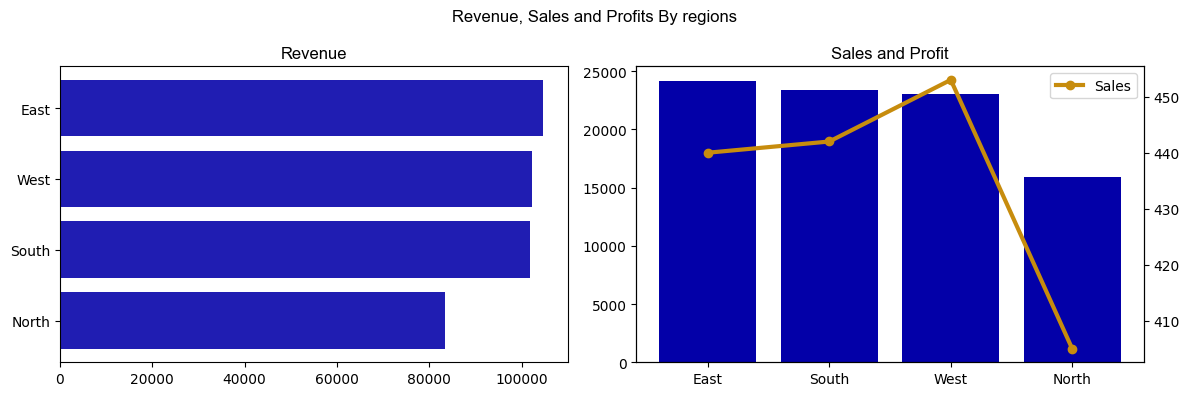

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plt.suptitle('Revenue, Sales and Profits By regions', fontname='arial')

rev_table.sort_values(by='Revenue', ascending=True, inplace=True)
ax[0].barh(rev_table['region'], rev_table['Revenue'], color="#0300A8E2")
ax[0].set_title('Revenue', fontname='arial')
rev_table.sort_values(by='Profit', ascending=False, inplace=True)
ax[1].bar(rev_table['region'], rev_table['Profit'], color="#0300A8")
ax[1].set_title('Sales and Profit', fontname='arial')
ax2 = ax[1].twinx()
ax2.plot(rev_table['region'], rev_table['Sales'], marker='o', linewidth=3,  color="#C78C0D", label='Sales')
plt.legend()
plt.tight_layout()


In [9]:
categories = df.groupby('product_category').agg(
    Revenue=('revenue', 'sum'),
    Sales=('units_sold', 'sum' ),
    Profit=('profit', 'sum')
).reset_index()

categories

,product_category,Revenue,Sales,Profit
0,Furniture,139528.7040,636,29699.1140
1,Office Supplies,144941.3665,641,32770.5565
2,Technology,107864.7600,463,24022.4200


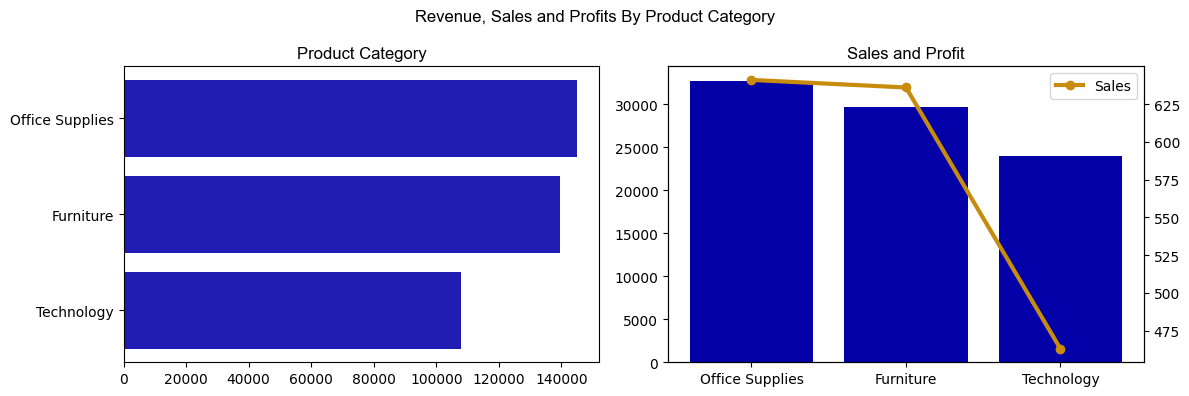

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plt.suptitle('Revenue, Sales and Profits By Product Category', fontname='arial')

categories.sort_values(by='Revenue',
                        ascending=True, inplace=True)
ax[0].barh(categories['product_category'], categories['Revenue'],
            color="#0300A8E2")
ax[0].set_title('Product Category', 
                fontname='arial')
categories.sort_values(by='Profit',
                        ascending=False, inplace=True)
ax[1].bar(categories['product_category'], categories['Profit'],
           color="#0300A8")
ax[1].set_title('Sales and Profit', 
                fontname='arial')
ax2 = ax[1].twinx()
ax2.plot(categories['product_category'], 
         categories['Sales'], marker='o', 
         color="#C78C0D", label='Sales', linewidth=3)
plt.legend()
plt.tight_layout()



*Product Sub_categories revenue and sales metrics*

In [11]:
sub_cat = df.groupby(['product_category', 'product_sub-category']).agg(
    Revenue=('revenue', 'sum'),
    Sales=('units_sold', 'sum'),
    Profit=('profit', 'sum')
).reset_index()






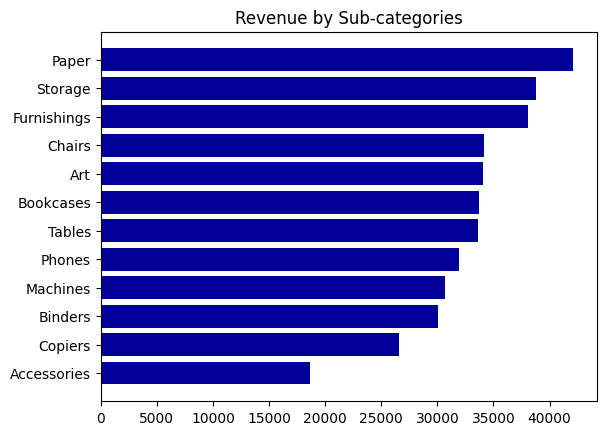

In [12]:
sub_cat.sort_values(by='Revenue', ascending=True, inplace=True)
furniture =sub_cat[sub_cat['product_category'] == 'Furniture']
office_sups = sub_cat[sub_cat['product_category'] == 'Office Supplies']
techs = sub_cat[sub_cat['product_category'] == 'Technology']
plt.barh(sub_cat['product_sub-category'], sub_cat['Revenue'], color='#000099')
plt.title("Revenue by Sub-categories")
plt.show()

*Plot for the subcatogories revenue*

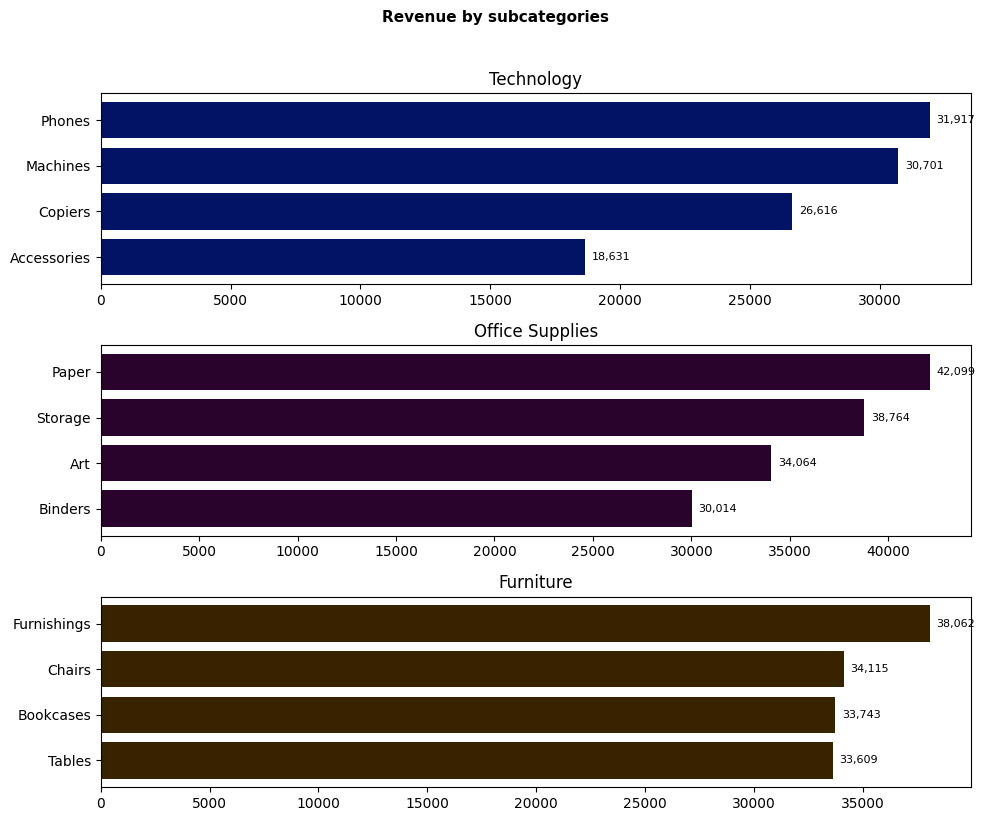

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8))

plt.suptitle("Revenue by subcategories", fontsize=11, fontweight='bold', y=1.02)


b2 = ax[2].barh(furniture['product_sub-category'], furniture['Revenue'], color='#382301')
ax[2].set_title('Furniture')
ax[2].bar_label(b2, fmt='{:,.0f}', padding=5, fontsize=8, color='black')


b1 = ax[1].barh(office_sups['product_sub-category'], office_sups['Revenue'], color='#29032b')
ax[1].set_title('Office Supplies')
ax[1].bar_label(b1, fmt='{:,.0f}', padding=5, fontsize=8, color='black')


b0 = ax[0].barh(techs['product_sub-category'], techs['Revenue'], color='#021366')
ax[0].set_title('Technology')
ax[0].bar_label(b0, fmt='{:,.0f}', padding=5, fontsize=8, color='black')



plt.tight_layout()
plt.show()

In [14]:
monthly_rev = df.groupby(['month', 'month_name'])['revenue'].sum().reset_index()

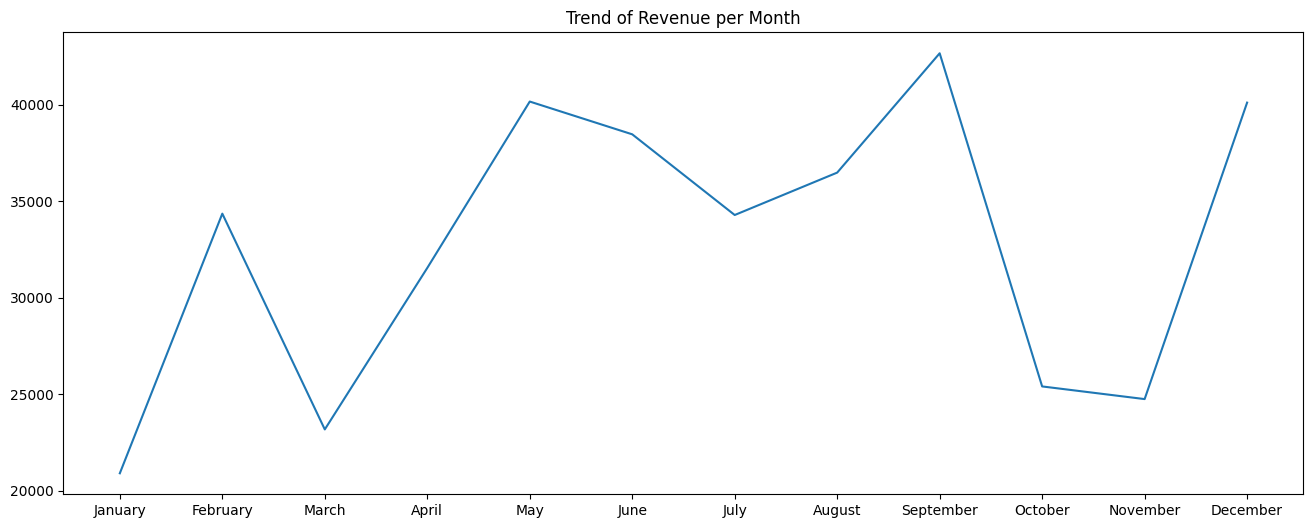

In [15]:

plt.figure(figsize=(16,6))
plt.plot(monthly_rev['month_name'], monthly_rev['revenue'])
plt.title("Trend of Revenue per Month")
plt.show()

In [16]:
quarterly_rev = df.groupby(['quarter'])['revenue'].sum().reset_index()
quarterly_rev['quarter'] = quarterly_rev['quarter'].astype(str)

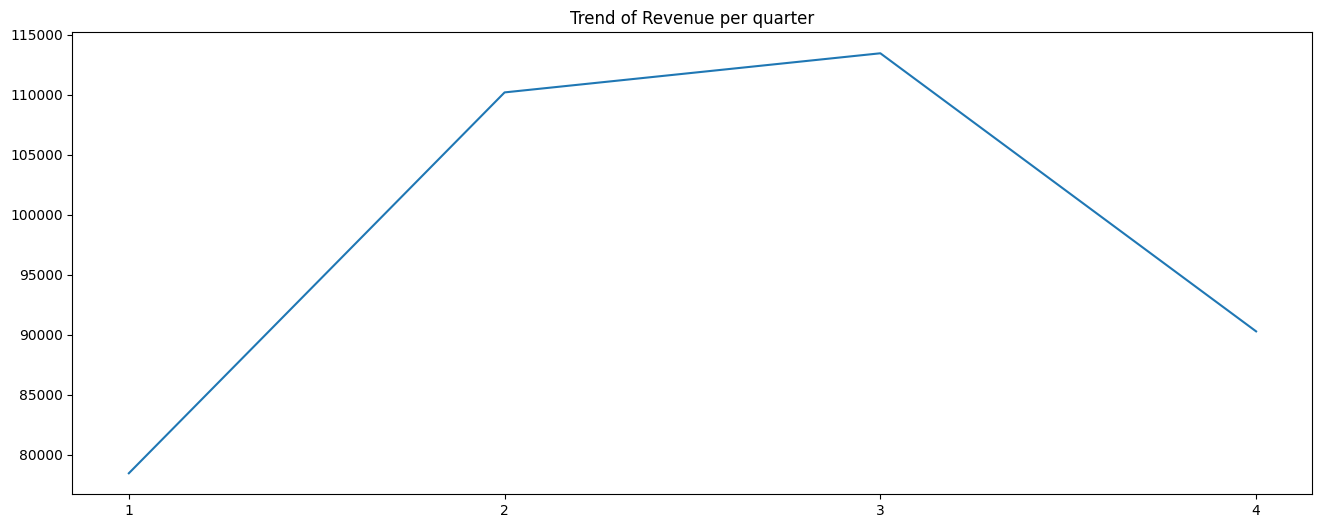

In [17]:
plt.figure(figsize=(16,6))
plt.plot(quarterly_rev['quarter'], quarterly_rev['revenue'])
plt.title("Trend of Revenue per quarter")
plt.show()

In [18]:
total_profit  = df['profit'].sum()

print(f'Total profit: {total_profit:,.2f}')

Total profit: 86,492.09


In [19]:
# Overall profit margin and profit by subcategory

profit_margin = (total_profit / Total_Revenue) * 100
print(f'Overall Profit Margin: {profit_margin:,.2f}')

Overall Profit Margin: 22.05


In [20]:

cat_margin = df.groupby('product_category').agg(
    Revenue=('revenue', 'sum'),
    Profit=('profit', 'sum')
).reset_index()

In [21]:
# categpries profit margin

cat_margin['Profit_margin'] = (cat_margin['Profit'] / cat_margin['Revenue']) * 100


In [22]:
cat_margin

,product_category,Revenue,Profit,Profit_margin
0,Furniture,139528.7040,29699.1140,21.285308
1,Office Supplies,144941.3665,32770.5565,22.609526
2,Technology,107864.7600,24022.4200,22.270870


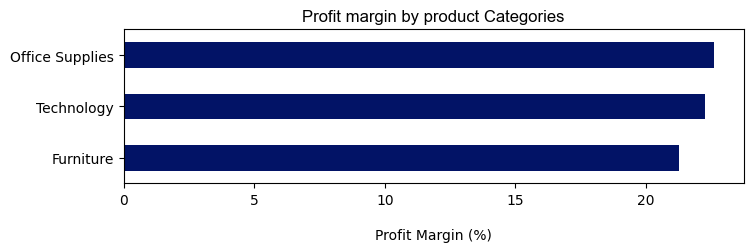

In [23]:
cat_margin.sort_values(by='Profit_margin', ascending=True, inplace=True)
cat_margin.set_index('product_category')['Profit_margin'].plot(
    kind='barh',
    figsize=(8,2),
    color='#021366'
)
plt.xlabel("Profit Margin (%)", labelpad=15)
plt.title("Profit margin by product Categories", fontname='arial')
plt.ylabel('')
plt.show()
# plt.yticks(rotation=70)

In [24]:
# Top Products: Sales

top_seller = df.groupby('product_name')['units_sold'].sum().reset_index().sort_values(
    by='units_sold', ascending=False).head(5)
top_profit = df.groupby('product_name')['profit'].sum().reset_index().sort_values(
    by='profit', ascending=False).head(5)
top_revenue = df.groupby('product_name')['revenue'].sum().reset_index().sort_values(
    by='revenue', ascending=False).head(5)


In [25]:
top_profit.sort_values(by='profit', ascending=True, inplace=True)
top_profit

,product_name,profit
21,SmartPhone A1,4982.6420
6,Desk Lamp,5068.5645
4,Comfort Seat,5314.9415
18,Printer Paper,5976.2545
17,Plastic Storage Box,6464.2495


In [26]:
top_revenue.sort_values(by='revenue', ascending=True, inplace=True)

In [27]:
top_seller.sort_values(by='units_sold', ascending=True, inplace=True)

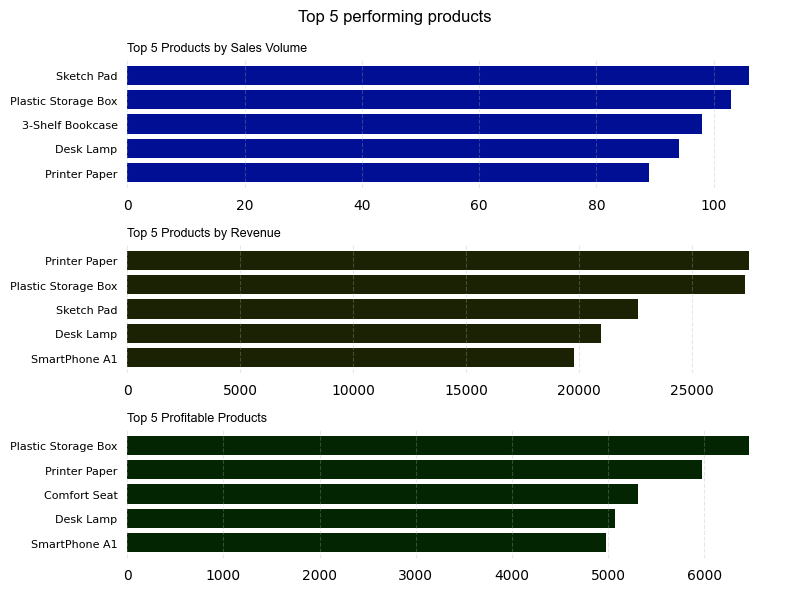

In [ ]:
#plot for op 5 performing products accross categories
fig, ax = plt.subplots(3,1, figsize=(8,6))
plt.suptitle('Top 5 performing products', fontname='arial')
ax[0].barh(top_seller['product_name'], top_seller['units_sold'], color="#000F94")
ax[0].set_title('Top 5 Products by Sales Volume', fontname='arial', fontsize=9,  loc='left')
ax[1].barh(top_revenue['product_name'], top_revenue['revenue'], color="#1A2203")
ax[1].set_title('Top 5 Products by Revenue', fontname='arial', fontsize=9,  loc='left')
ax[2].barh(top_profit['product_name'], top_profit['profit'], color="#032501")
ax[2].set_title('Top 5 Profitable Products', fontname='arial', fontsize=9, loc='left')

#format and clean chart

for charts in ax:
    for spines in charts.spines.values():
        spines.set_visible(False)
    
    charts.tick_params(left = False, bottom=False)
    charts.tick_params(axis='y', labelsize=8)

    charts.grid(axis='x', linestyle='--', alpha=0.3)


plt.tight_layout()


In [29]:
avg_discount = df.groupby('product_category')['discount_(%)'].mean().reset_index()

avg_discount = avg_discount.sort_values(by='discount_(%)', ascending=False)
display(avg_discount)

,product_category,discount_(%)
0,Furniture,0.140196
1,Office Supplies,0.127119
2,Technology,0.126250


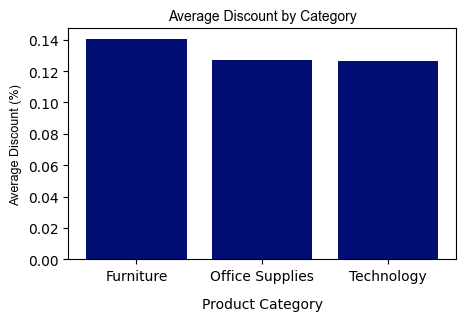

In [30]:

#plot for average discount
plt.figure(figsize=(5,3))
plt.bar(avg_discount['product_category'], avg_discount['discount_(%)'], color="#030E74")
plt.title('Average Discount by Category', fontsize=10
          , fontname='arial')
plt.xlabel('Product Category', labelpad=10)
plt.ylabel('Average Discount (%)', fontsize=9, fontname='arial')
plt.xticks(rotation=0)
plt.show()

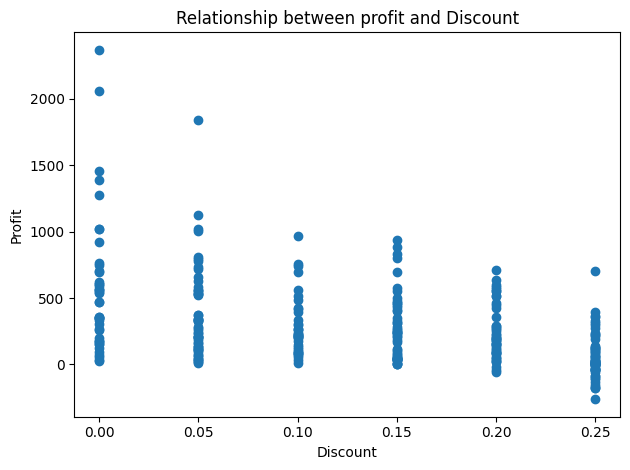

In [36]:
plt.scatter(df['discount_(%)'], df['profit'])
plt.ylabel('Profit')
plt.xlabel("Discount")
plt.title("Relationship between profit and Discount")
plt.tight_layout()
plt.show()


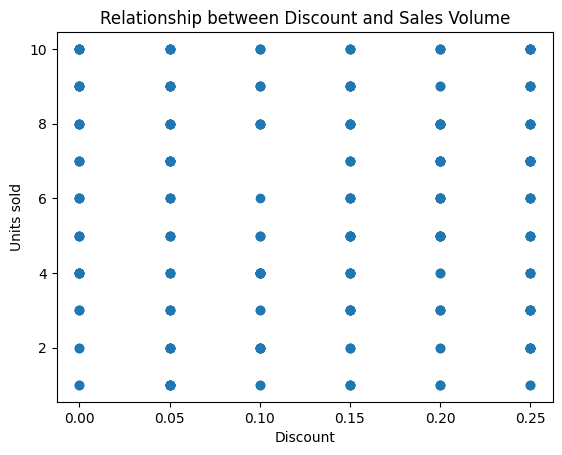

In [34]:
plt.scatter(df['discount_(%)'], df['units_sold'])
plt.ylabel('Units sold')
plt.xlabel("Discount")
plt.title("Relationship between Discount and Sales Volume")
plt.show()


In [79]:
top_rev_cust = df.groupby('customer_name')['revenue'].sum().reset_index().sort_values(
    by='revenue', ascending=False).head(5)

top_profit_cust = df.groupby('customer_name')['profit'].sum().reset_index().sort_values(
    by='profit', ascending=False).head(5)

top_sales_cust = df.groupby('customer_name')['units_sold'].sum().reset_index().sort_values(
    by='units_sold', ascending=False).head(5)

top_repeat_cust = df.groupby('customer_name')['customer_name'].value_counts().reset_index().sort_values(
    by='count', ascending=False).head(5)

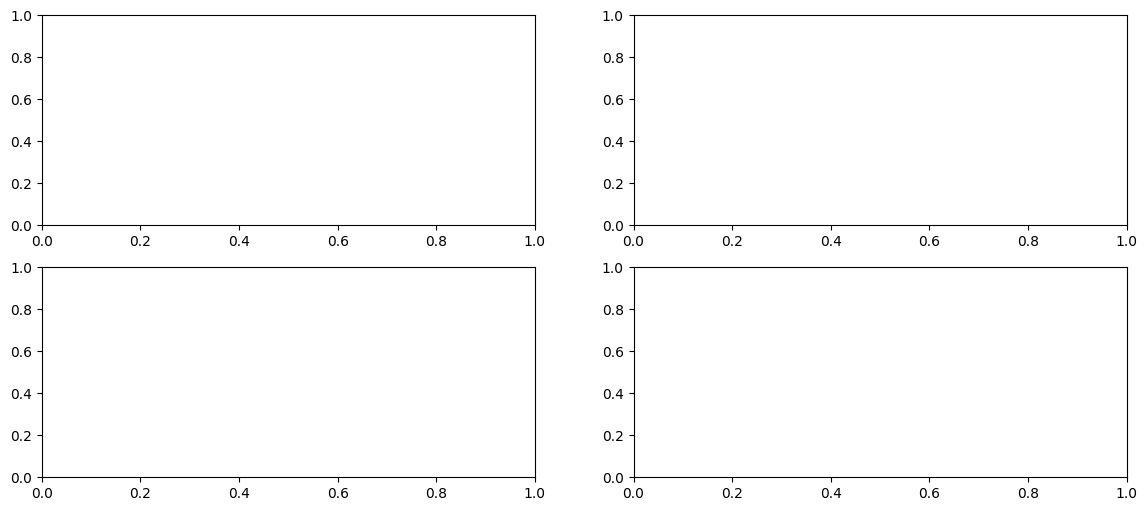

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(14,6))
plt.suptitle("Top Customers accross various metrics")